In [6]:
!pip install scikit-learn

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import warnings
warnings.filterwarnings("ignore")

#Basic EDA

In [4]:
df=pd.read_csv('loan_detection.csv')
df

,age,campaign,pdays,previous,no_previous_contact,not_working,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,...,month_sep,day_of_week_fri,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_failure,poutcome_nonexistent,poutcome_success,Loan_Status_label
0,56,1,999,0,1,0,0,0,0,1,...,0,0,1,0,0,0,0,1,0,0
1,57,1,999,0,1,0,0,0,0,0,...,0,0,1,0,0,0,0,1,0,0
2,37,1,999,0,1,0,0,0,0,0,...,0,0,1,0,0,0,0,1,0,0
3,40,1,999,0,1,0,1,0,0,0,...,0,0,1,0,0,0,0,1,0,0
4,56,1,999,0,1,0,0,0,0,0,...,0,0,1,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,1,999,0,1,1,0,0,0,0,...,0,1,0,0,0,0,0,1,0,1
41184,46,1,999,0,1,0,0,1,0,0,...,0,1,0,0,0,0,0,1,0,0
41185,56,2,999,0,1,1,0,0,0,0,...,0,1,0,0,0,0,0,1,0,0
41186,44,1,999,0,1,0,0,0,0,0,...,0,1,0,0,0,0,0,1,0,1


#Statistical Analysis

In [10]:
df.shape

(41188, 60)

In [11]:
df.columns

Index(['age', 'campaign', 'pdays', 'previous', 'no_previous_contact',
       'not_working', 'job_admin.', 'job_blue-collar', 'job_entrepreneur',
       'job_housemaid', 'job_management', 'job_retired', 'job_self-employed',
       'job_services', 'job_student', 'job_technician', 'job_unemployed',
       'job_unknown', 'marital_divorced', 'marital_married', 'marital_single',
       'marital_unknown', 'education_basic.4y', 'education_basic.6y',
       'education_basic.9y', 'education_high.school', 'education_illiterate',
       'education_professional.course', 'education_university.degree',
       'education_unknown', 'default_no', 'default_unknown', 'default_yes',
       'housing_no', 'housing_unknown', 'housing_yes', 'loan_no',
       'loan_unknown', 'loan_yes', 'contact_cellular', 'contact_telephone',
       'month_apr', 'month_aug', 'month_dec', 'month_jul', 'month_jun',
       'month_mar', 'month_may', 'month_nov', 'month_oct', 'month_sep',
       'day_of_week_fri', 'day_of_week_mon'

In [12]:
df.info

<bound method DataFrame.info of        age  campaign  pdays  previous  no_previous_contact  not_working  \
0       56         1    999         0                    1            0   
1       57         1    999         0                    1            0   
2       37         1    999         0                    1            0   
3       40         1    999         0                    1            0   
4       56         1    999         0                    1            0   
...    ...       ...    ...       ...                  ...          ...   
41183   73         1    999         0                    1            1   
41184   46         1    999         0                    1            0   
41185   56         2    999         0                    1            1   
41186   44         1    999         0                    1            0   
41187   74         3    999         1                    1            1   

       job_admin.  job_blue-collar  job_entrepreneur  job_housemaid

In [13]:
df.describe()

,age,campaign,pdays,previous,no_previous_contact,not_working,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,...,month_sep,day_of_week_fri,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_failure,poutcome_nonexistent,poutcome_success,Loan_Status_label
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,...,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,2.567593,962.475454,0.172963,0.963217,0.087623,0.253035,0.224677,0.035350,0.025736,...,0.013839,0.190031,0.206711,0.209357,0.196416,0.197485,0.103234,0.863431,0.033335,0.112654
std,10.42125,2.770014,186.910907,0.494901,0.188230,0.282749,0.434756,0.417375,0.184665,0.158348,...,0.116824,0.392330,0.404951,0.406855,0.397292,0.398106,0.304268,0.343396,0.179512,0.316173
min,17.00000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,32.00000,1.000000,999.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
50%,38.00000,2.000000,999.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
75%,47.00000,3.000000,999.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
max,98.00000,56.000000,999.000000,7.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


Missing values

In [14]:
df.isnull().sum()

age                              0
campaign                         0
pdays                            0
previous                         0
no_previous_contact              0
not_working                      0
job_admin.                       0
job_blue-collar                  0
job_entrepreneur                 0
job_housemaid                    0
job_management                   0
job_retired                      0
job_self-employed                0
job_services                     0
job_student                      0
job_technician                   0
job_unemployed                   0
job_unknown                      0
marital_divorced                 0
marital_married                  0
marital_single                   0
marital_unknown                  0
education_basic.4y               0
education_basic.6y               0
education_basic.9y               0
education_high.school            0
education_illiterate             0
education_professional.course    0
education_university

In [ ]:
#No missing values

Duplicate values

In [6]:
df.duplicated().sum()

np.int64(2417)

In [7]:
df.drop_duplicates(keep='first',inplace=True)

In [8]:
df.duplicated().sum()

np.int64(0)

#Outliers

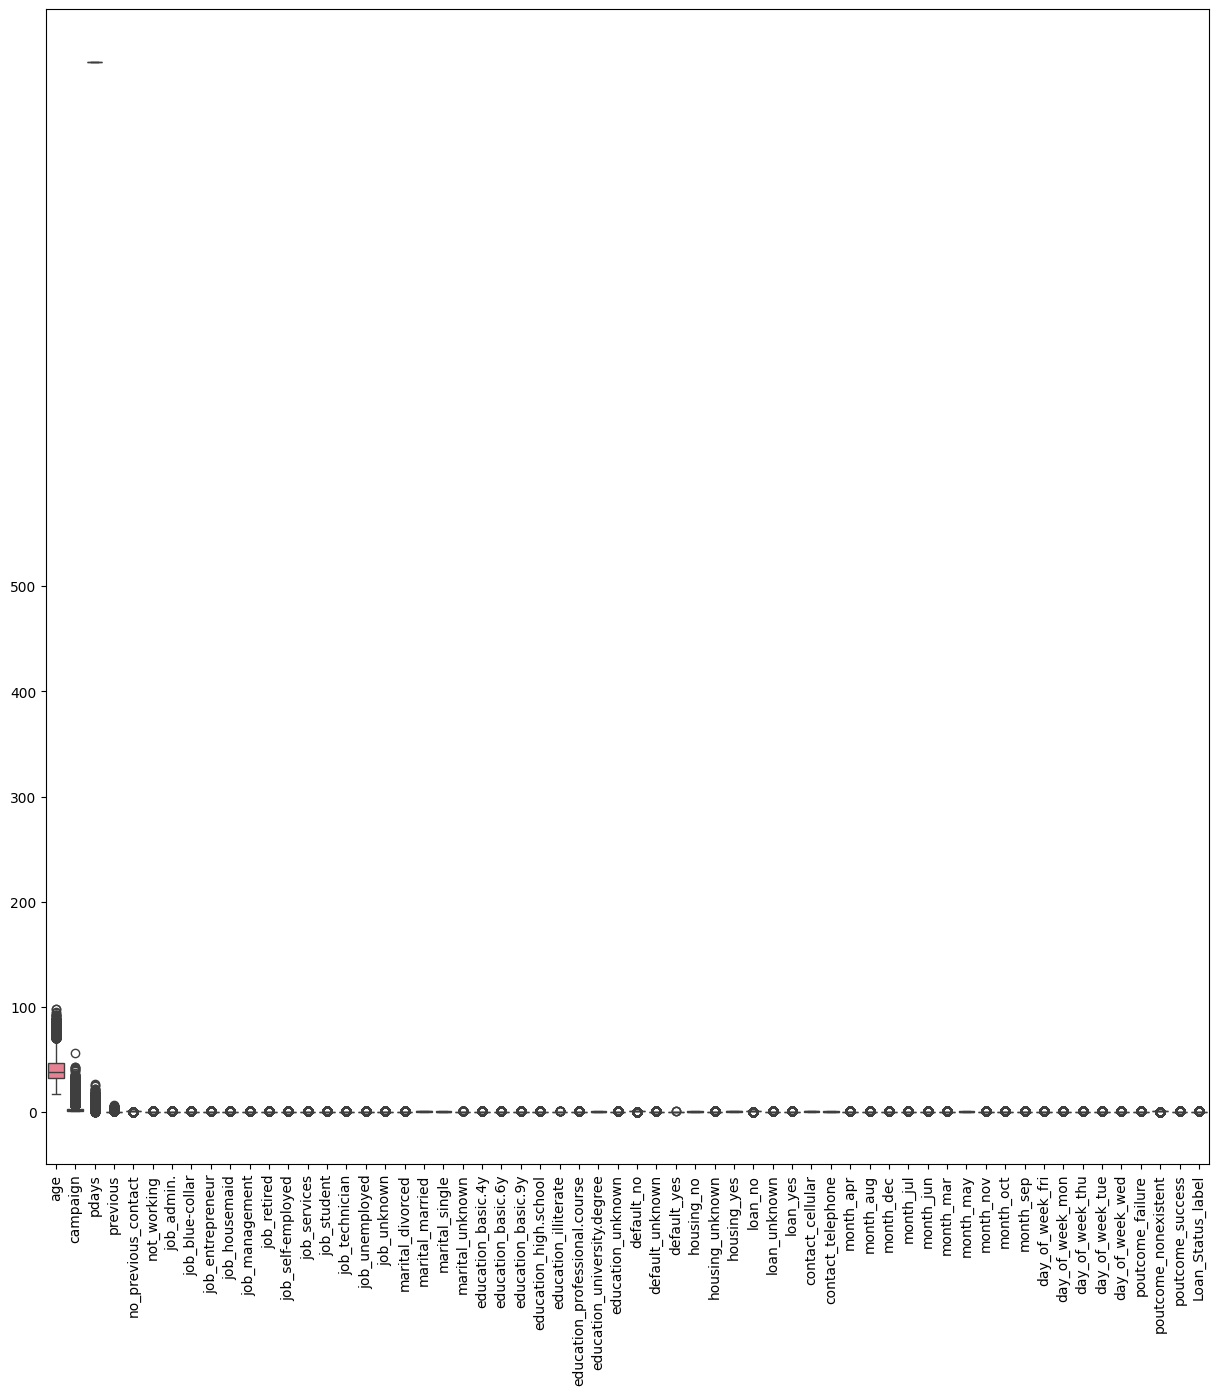

In [31]:
#boxplot
plt.figure(figsize=(15, 15))
sns.boxplot(df)
plt.xticks(rotation=90)
plt.yticks(np.arange(0, 600, step=100))
plt.show()

-------------- age --------------



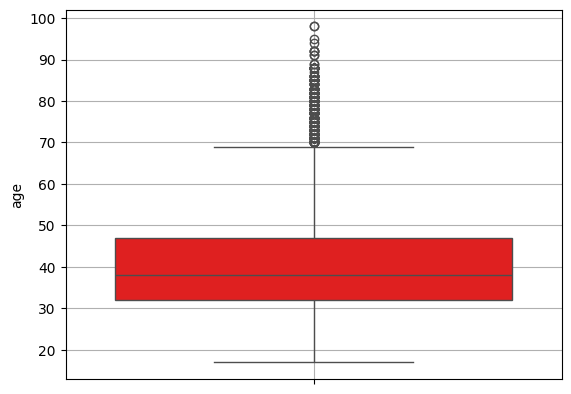

-------------- campaign --------------



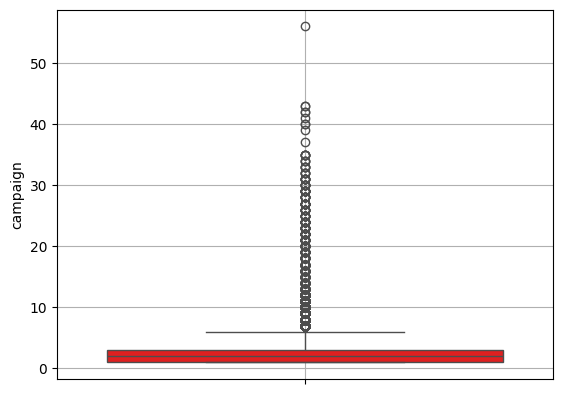

-------------- pdays --------------



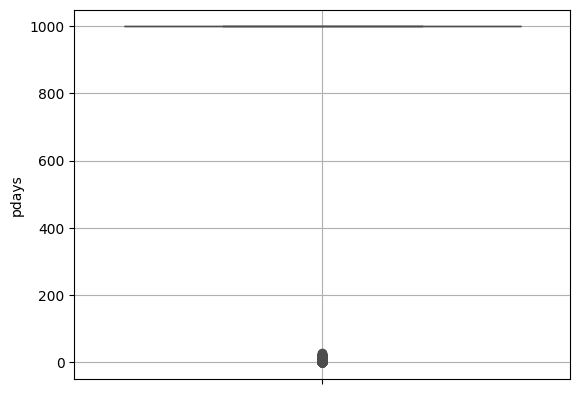

-------------- previous --------------



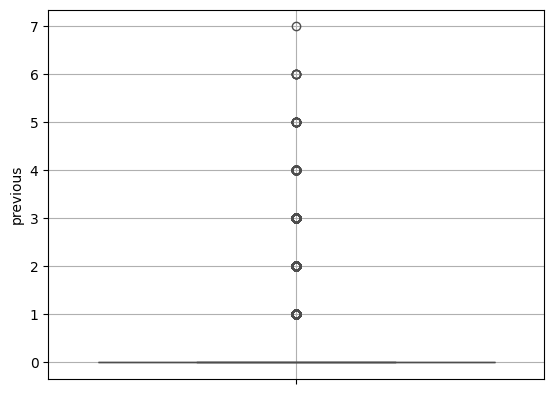

-------------- no_previous_contact --------------



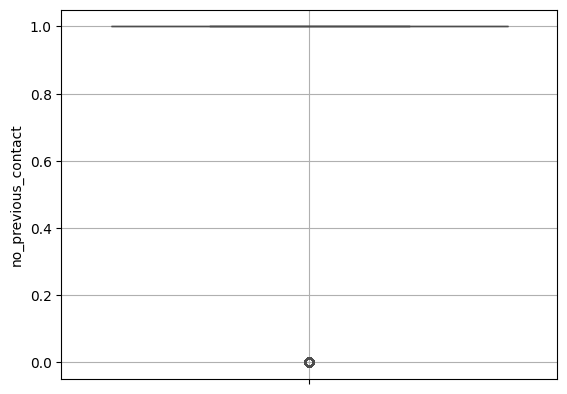

-------------- not_working --------------



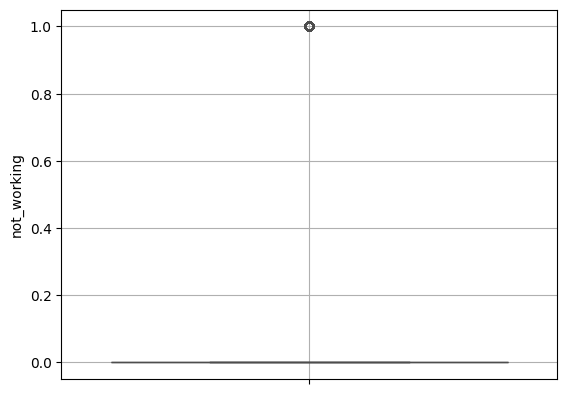

-------------- job_admin. --------------



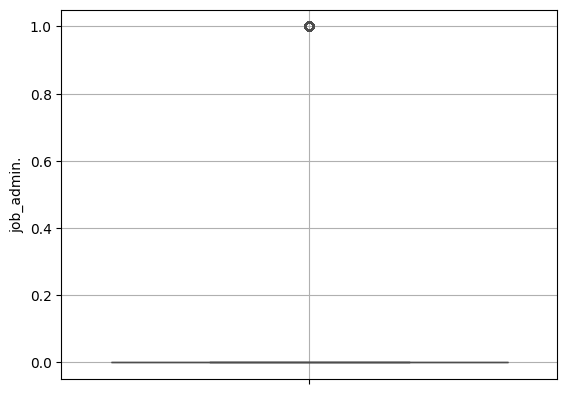

-------------- job_blue-collar --------------



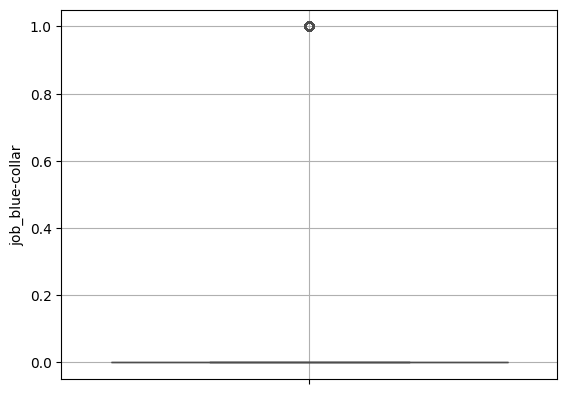

-------------- job_entrepreneur --------------



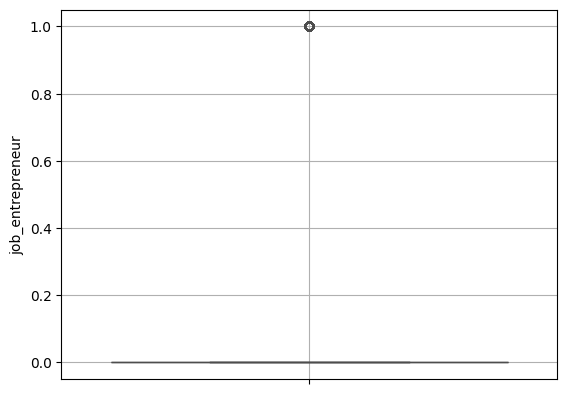

-------------- job_housemaid --------------



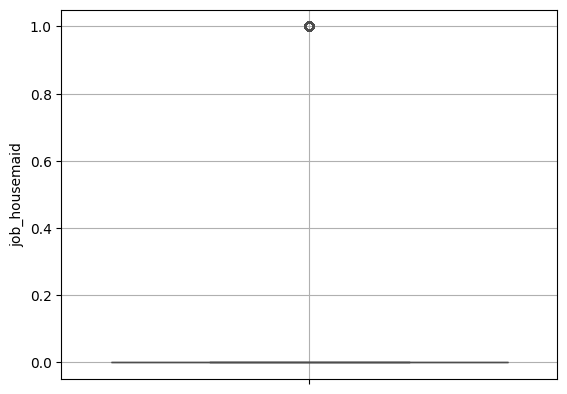

-------------- job_management --------------



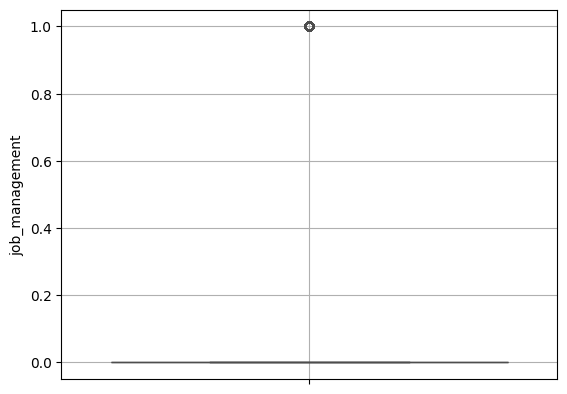

-------------- job_retired --------------



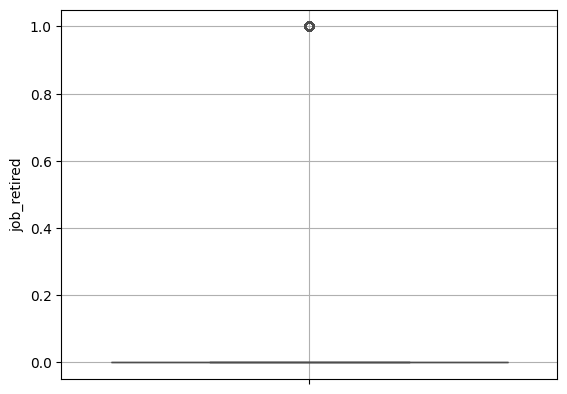

-------------- job_self-employed --------------



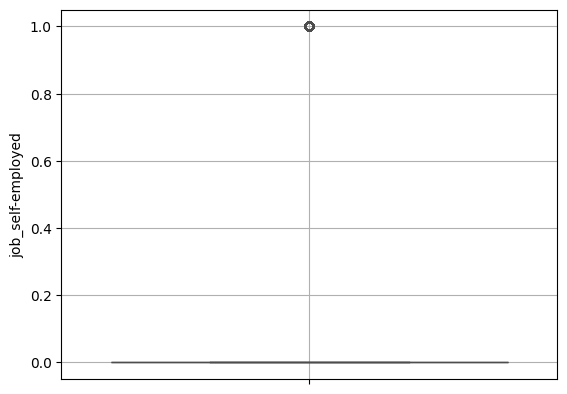

-------------- job_services --------------



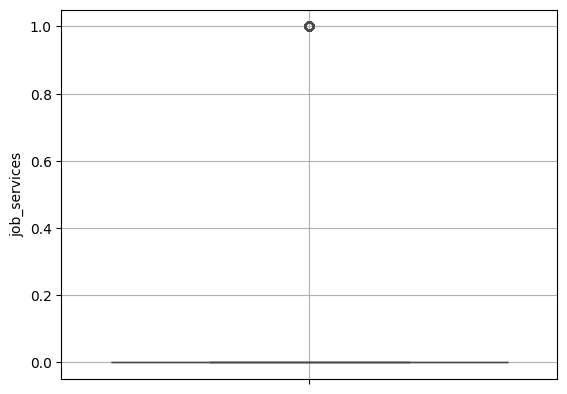

-------------- job_student --------------



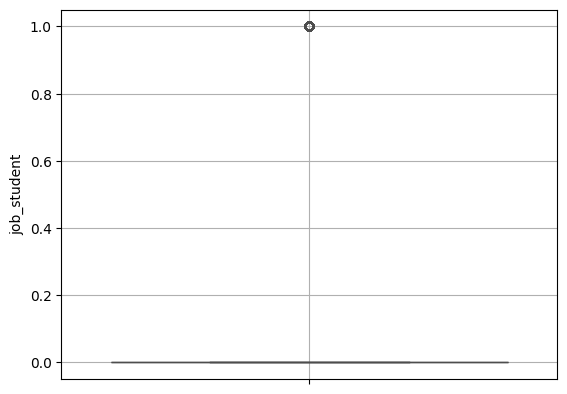

-------------- job_technician --------------



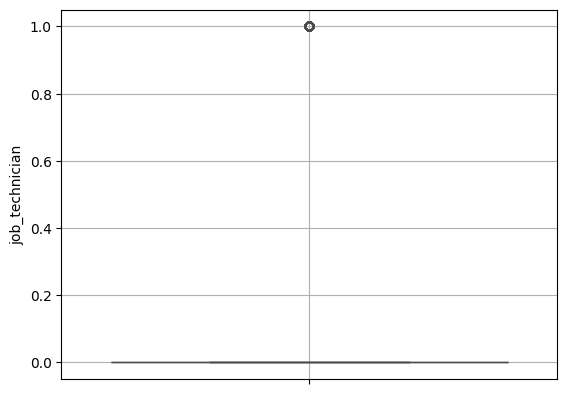

-------------- job_unemployed --------------



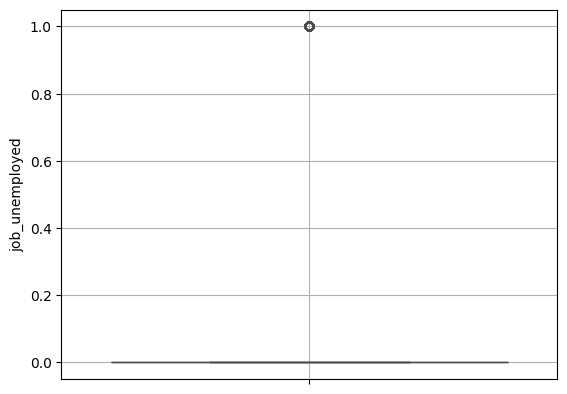

-------------- job_unknown --------------



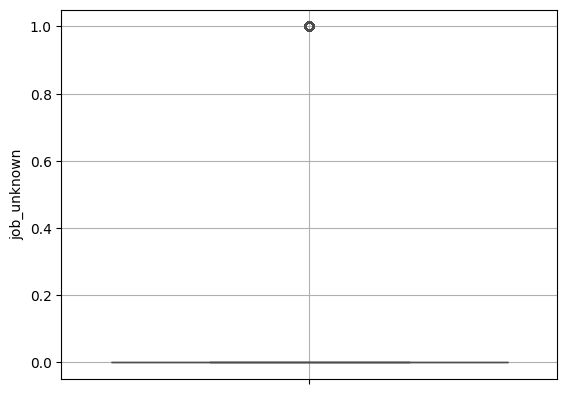

-------------- marital_divorced --------------



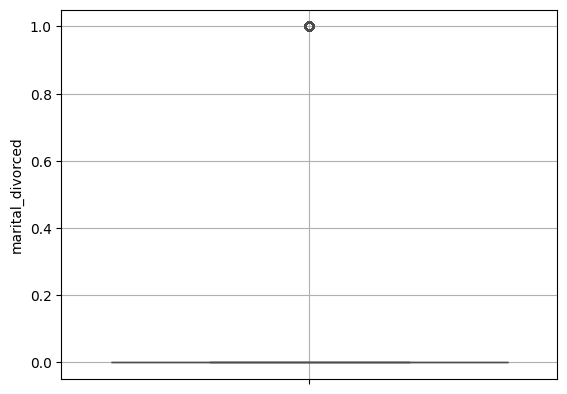

-------------- marital_single --------------



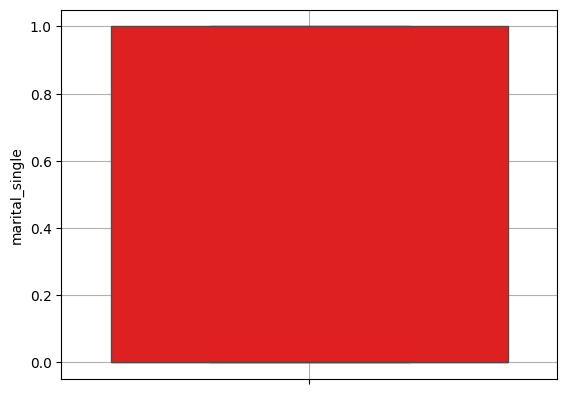

-------------- marital_unknown --------------



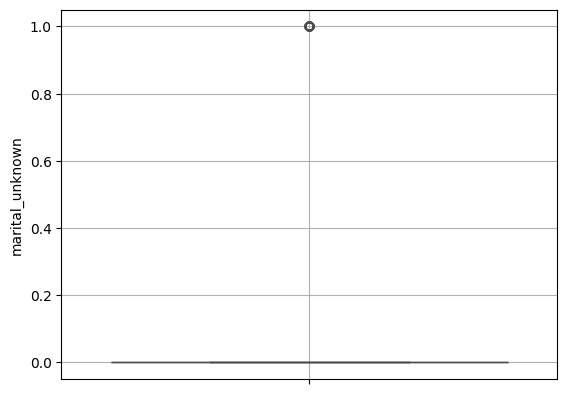

-------------- education_basic.4y --------------



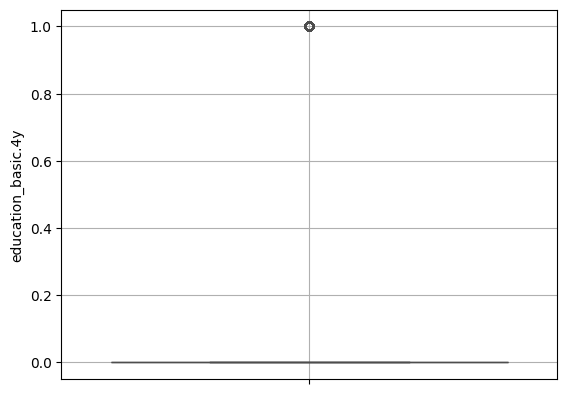

-------------- education_basic.6y --------------



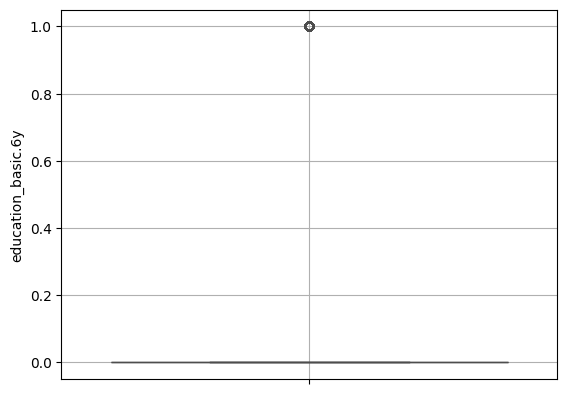

-------------- education_basic.9y --------------



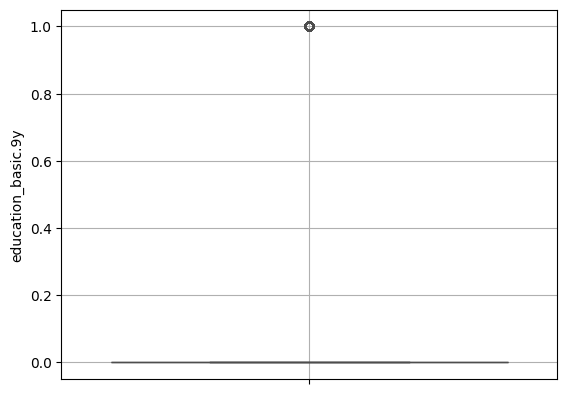

-------------- education_high.school --------------



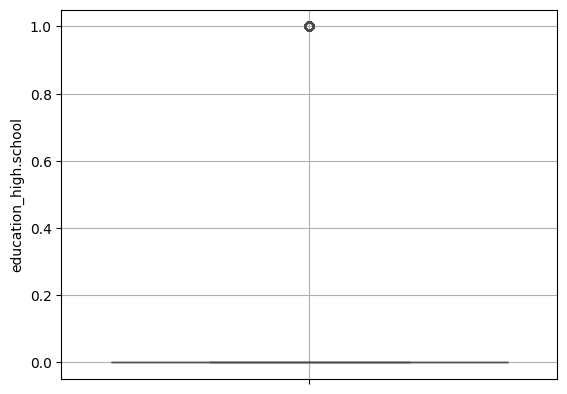

-------------- education_illiterate --------------



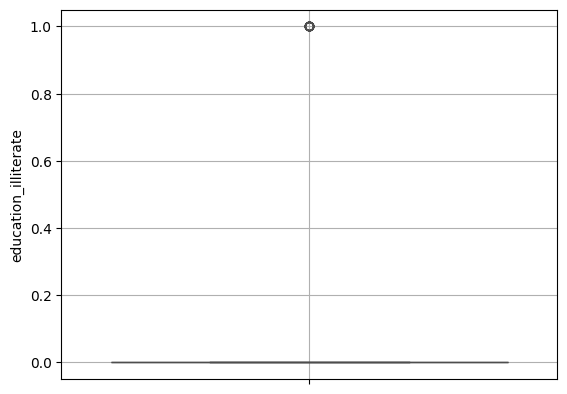

-------------- education_professional.course --------------



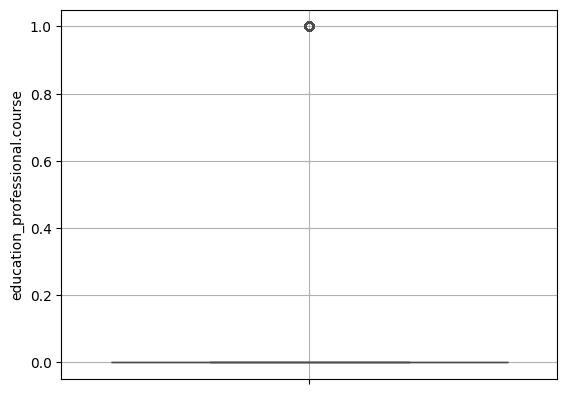

-------------- education_unknown --------------



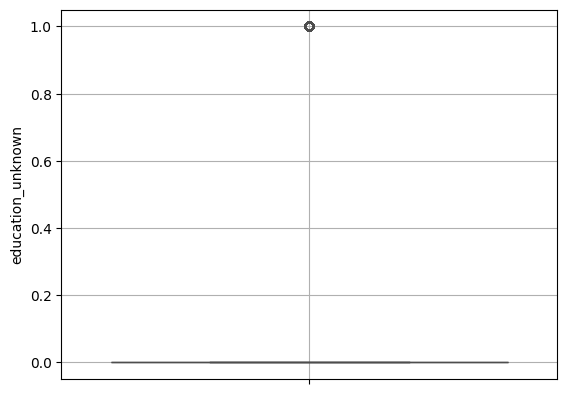

-------------- default_no --------------



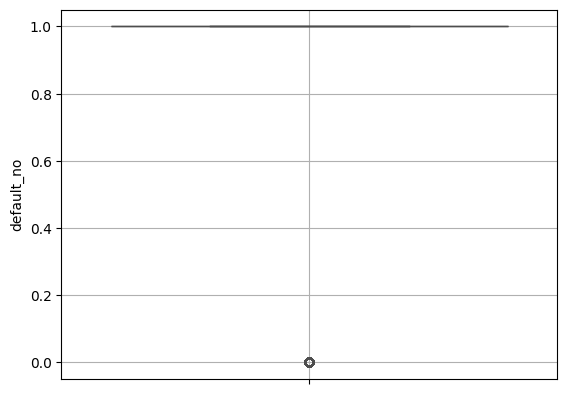

-------------- default_unknown --------------



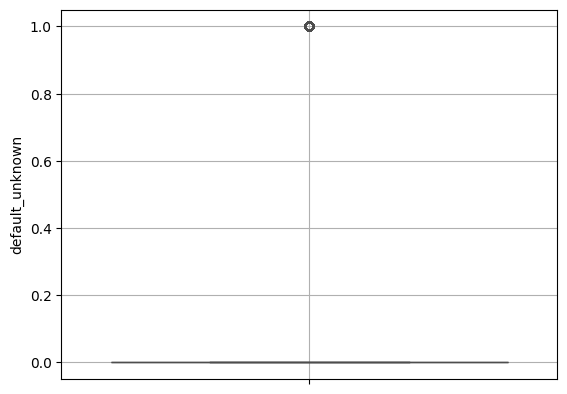

-------------- default_yes --------------



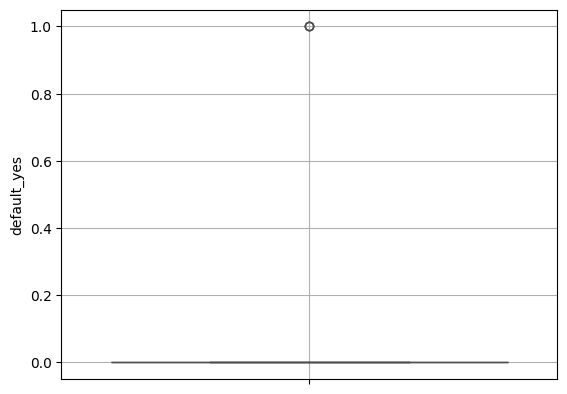

-------------- housing_unknown --------------



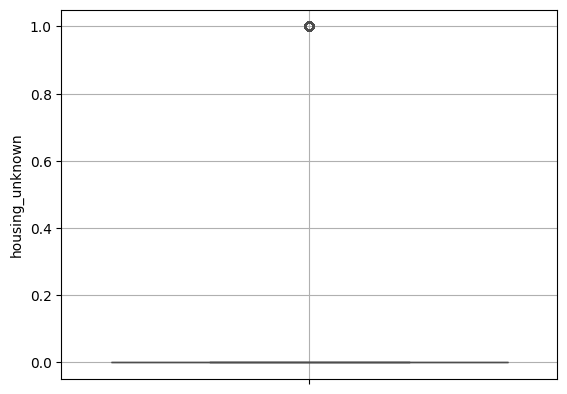

-------------- loan_no --------------



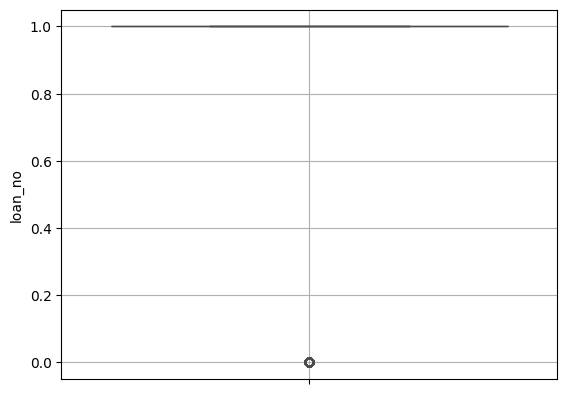

-------------- loan_unknown --------------



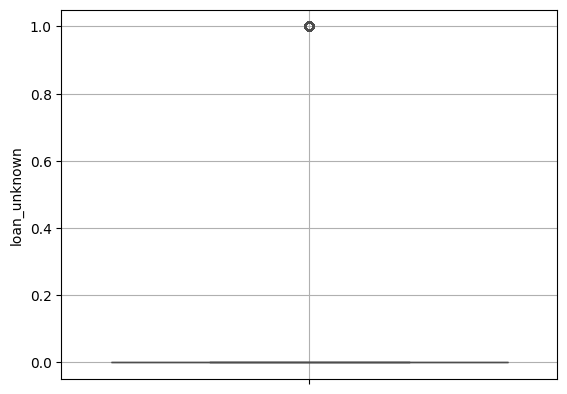

-------------- loan_yes --------------



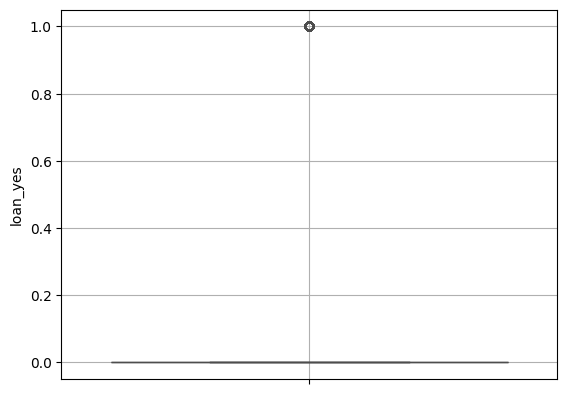

-------------- month_apr --------------



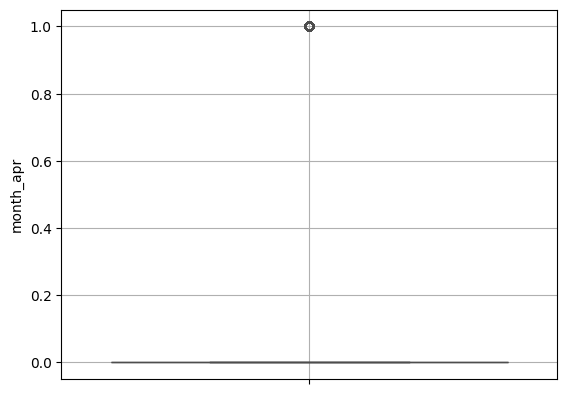

-------------- month_aug --------------



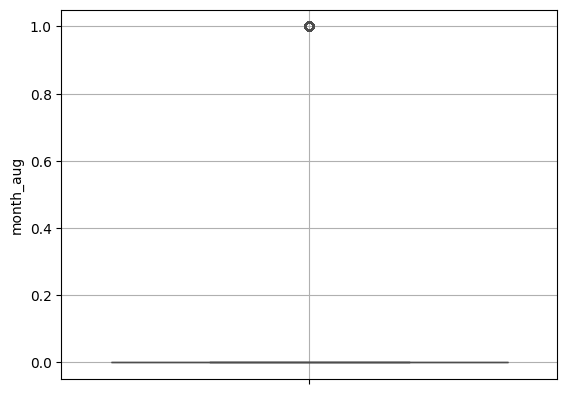

-------------- month_dec --------------



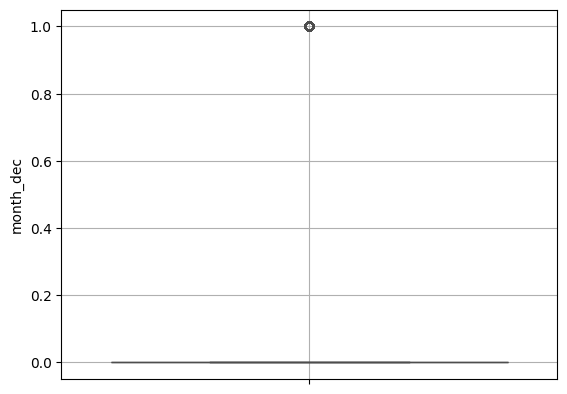

-------------- month_jul --------------



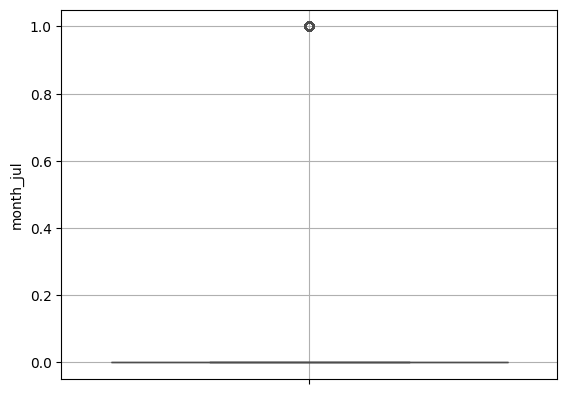

-------------- month_jun --------------



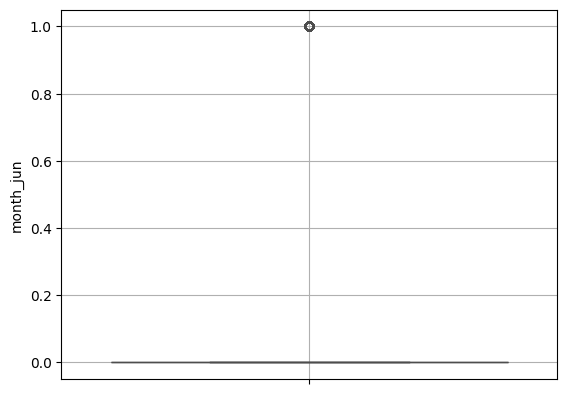

-------------- month_mar --------------



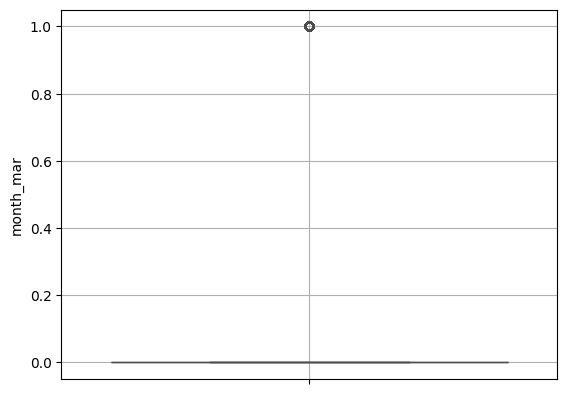

-------------- month_nov --------------



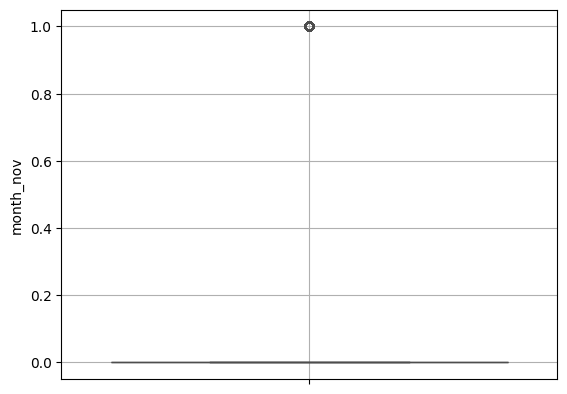

-------------- month_oct --------------



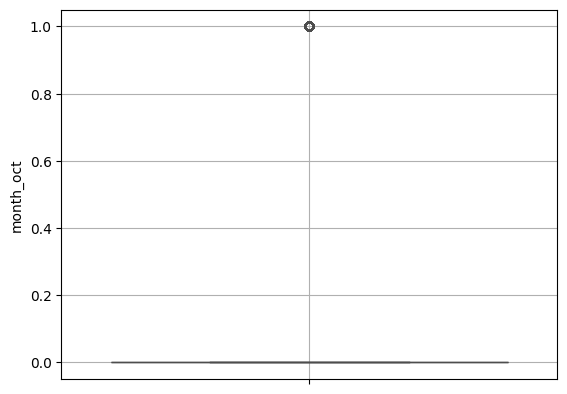

-------------- month_sep --------------



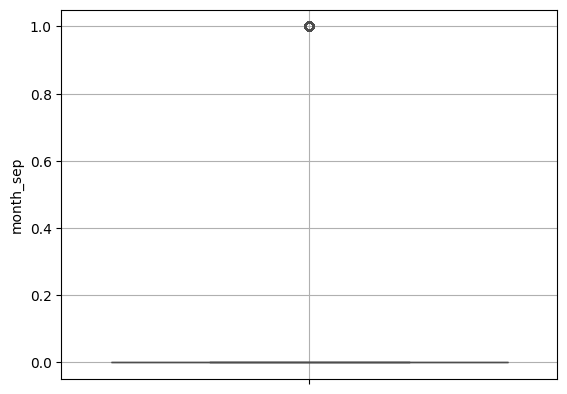

-------------- day_of_week_fri --------------



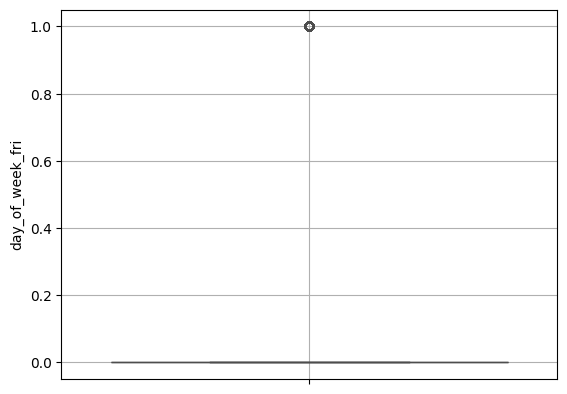

-------------- day_of_week_mon --------------



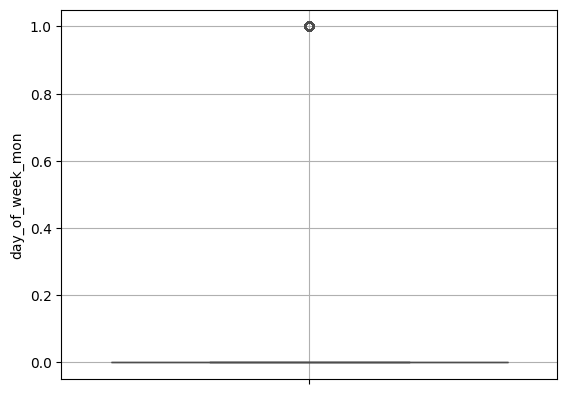

-------------- day_of_week_thu --------------



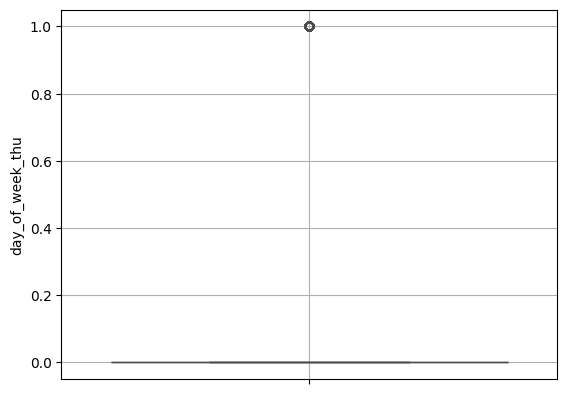

-------------- day_of_week_tue --------------



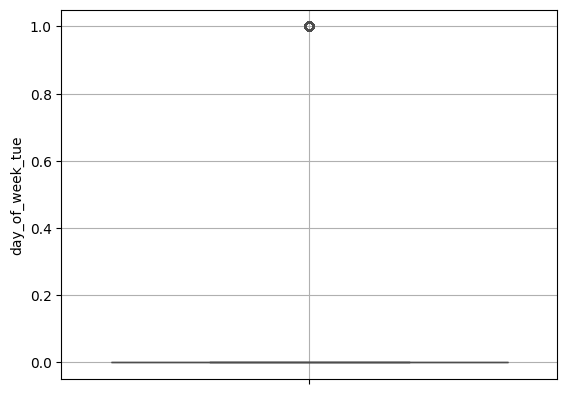

-------------- day_of_week_wed --------------



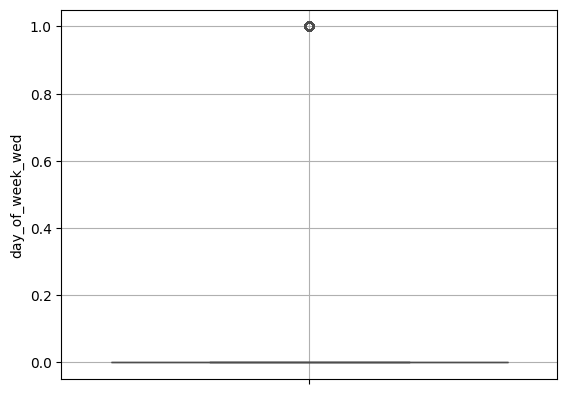

-------------- poutcome_failure --------------



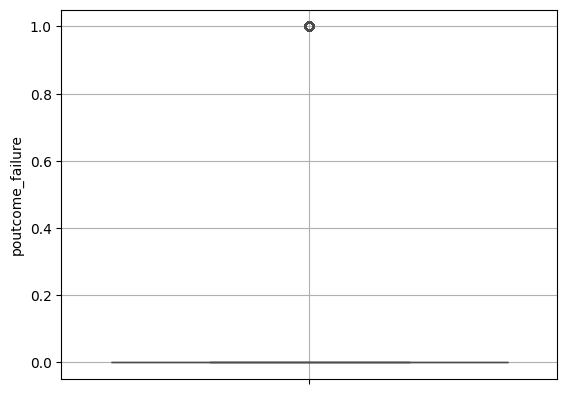

-------------- poutcome_nonexistent --------------



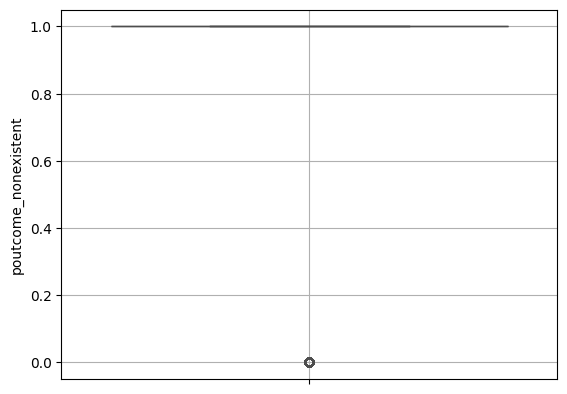

-------------- poutcome_success --------------



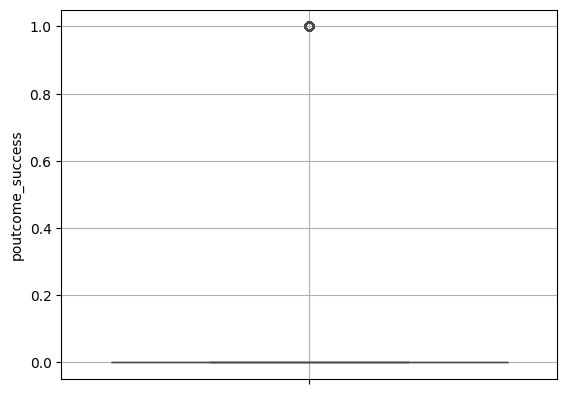

-------------- Loan_Status_label --------------



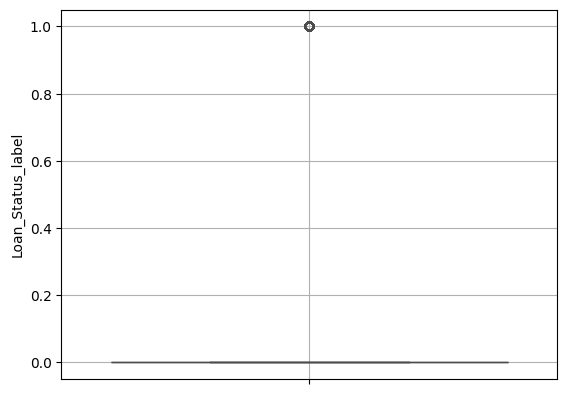

In [32]:
for i in df.columns:
    if i in ["marital_married", "martial_single", "education_university.degree","housing_no","housing_no","housing_yes","contact_cellular","contact_telephone","month_may"]:
        pass
    else:
        print(f'-------------- {i} --------------\n')
        sns.boxplot(df[i],color='r')
        plt.grid()
        plt.show()

Using IQR (removing outliers)

In [10]:
#IQR

Q1= df.quantile(0.25)
Q3= df.quantile(0.75)

IQR=Q3-Q1
print(f'IQR : \n\n{IQR}')

IQR : 

age                              15.0
campaign                          2.0
pdays                             0.0
previous                          0.0
no_previous_contact               0.0
not_working                       0.0
job_admin.                        0.0
job_blue-collar                   0.0
job_entrepreneur                  0.0
job_housemaid                     0.0
job_management                    0.0
job_retired                       0.0
job_self-employed                 0.0
job_services                      0.0
job_student                       0.0
job_technician                    0.0
job_unemployed                    0.0
job_unknown                       0.0
marital_divorced                  0.0
marital_married                   1.0
marital_single                    1.0
marital_unknown                   0.0
education_basic.4y                0.0
education_basic.6y                0.0
education_basic.9y                0.0
education_high.school             0.0
educ

In [11]:
lower= Q1 - 1.5*IQR
upper= Q3 + 1.5*IQR

print(f'Lower bound for outliers: \n\n{lower}\n\n')
print(f'Upper bound for outliers: \n\n{upper}')

Lower bound for outliers: 

age                                9.5
campaign                          -2.0
pdays                            999.0
previous                           0.0
no_previous_contact                1.0
not_working                        0.0
job_admin.                         0.0
job_blue-collar                    0.0
job_entrepreneur                   0.0
job_housemaid                      0.0
job_management                     0.0
job_retired                        0.0
job_self-employed                  0.0
job_services                       0.0
job_student                        0.0
job_technician                     0.0
job_unemployed                     0.0
job_unknown                        0.0
marital_divorced                   0.0
marital_married                   -1.5
marital_single                    -1.5
marital_unknown                    0.0
education_basic.4y                 0.0
education_basic.6y                 0.0
education_basic.9y                 0

In [12]:
df.shape

(38771, 60)

In [13]:
df[((df<lower) | (df>upper)).any(axis=1)]

,age,campaign,pdays,previous,no_previous_contact,not_working,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,...,month_sep,day_of_week_fri,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_failure,poutcome_nonexistent,poutcome_success,Loan_Status_label
0,56,1,999,0,1,0,0,0,0,1,...,0,0,1,0,0,0,0,1,0,0
1,57,1,999,0,1,0,0,0,0,0,...,0,0,1,0,0,0,0,1,0,0
2,37,1,999,0,1,0,0,0,0,0,...,0,0,1,0,0,0,0,1,0,0
3,40,1,999,0,1,0,1,0,0,0,...,0,0,1,0,0,0,0,1,0,0
4,56,1,999,0,1,0,0,0,0,0,...,0,0,1,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,1,999,0,1,1,0,0,0,0,...,0,1,0,0,0,0,0,1,0,1
41184,46,1,999,0,1,0,0,1,0,0,...,0,1,0,0,0,0,0,1,0,0
41185,56,2,999,0,1,1,0,0,0,0,...,0,1,0,0,0,0,0,1,0,0
41186,44,1,999,0,1,0,0,0,0,0,...,0,1,0,0,0,0,0,1,0,1


In [37]:
df[~((df<lower)| (df>upper)).any(axis=1)]

,age,campaign,pdays,previous,no_previous_contact,not_working,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,...,month_sep,day_of_week_fri,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_failure,poutcome_nonexistent,poutcome_success,Loan_Status_label


In [14]:
df

,age,campaign,pdays,previous,no_previous_contact,not_working,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,...,month_sep,day_of_week_fri,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_failure,poutcome_nonexistent,poutcome_success,Loan_Status_label
0,56,1,999,0,1,0,0,0,0,1,...,0,0,1,0,0,0,0,1,0,0
1,57,1,999,0,1,0,0,0,0,0,...,0,0,1,0,0,0,0,1,0,0
2,37,1,999,0,1,0,0,0,0,0,...,0,0,1,0,0,0,0,1,0,0
3,40,1,999,0,1,0,1,0,0,0,...,0,0,1,0,0,0,0,1,0,0
4,56,1,999,0,1,0,0,0,0,0,...,0,0,1,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,1,999,0,1,1,0,0,0,0,...,0,1,0,0,0,0,0,1,0,1
41184,46,1,999,0,1,0,0,1,0,0,...,0,1,0,0,0,0,0,1,0,0
41185,56,2,999,0,1,1,0,0,0,0,...,0,1,0,0,0,0,0,1,0,0
41186,44,1,999,0,1,0,0,0,0,0,...,0,1,0,0,0,0,0,1,0,1


Feature selection

In [15]:
df.corr()

,age,campaign,pdays,previous,no_previous_contact,not_working,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,...,month_sep,day_of_week_fri,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_failure,poutcome_nonexistent,poutcome_success,Loan_Status_label
age,1.000000,-0.000792,-0.032680,0.020430,-0.032600,0.207835,-0.095507,-0.030068,0.027431,0.084198,...,0.040026,0.006287,0.017340,-0.019094,0.017902,-0.022350,-0.007085,-0.011749,0.034118,0.026865
campaign,-0.000792,1.000000,0.057855,-0.086774,0.057840,-0.021846,0.015630,0.000038,-0.004086,0.002921,...,-0.036927,0.025805,0.010532,0.007932,-0.024070,-0.020438,-0.075279,0.096142,-0.055900,-0.074539
pdays,-0.032680,0.057855,1.000000,-0.588940,0.999992,-0.112069,-0.028564,0.066963,0.020523,-0.000918,...,-0.154564,0.014940,0.002517,-0.009324,-0.008213,0.000339,0.009098,0.493971,-0.950559,-0.324611
previous,0.020430,-0.086774,-0.588940,1.000000,-0.588887,0.103602,0.023149,-0.056865,-0.015668,-0.012511,...,0.157224,0.003027,-0.004078,0.002367,0.001799,-0.003039,0.678092,-0.877385,0.525045,0.228665
no_previous_contact,-0.032600,0.057840,0.999992,-0.588887,1.000000,-0.112069,-0.028578,0.066956,0.020524,-0.000907,...,-0.154550,0.014932,0.002493,-0.009325,-0.008194,0.000353,0.008844,0.493975,-0.950141,-0.324572
not_working,0.207835,-0.021846,-0.112069,0.103602,-0.112069,1.000000,-0.181604,-0.169473,-0.061192,-0.051962,...,0.084659,0.001643,-0.006026,-0.001012,0.007139,-0.001549,0.031470,-0.082430,0.103344,0.118294
job_admin.,-0.095507,0.015630,-0.028564,0.023149,-0.028578,-0.181604,1.000000,-0.308601,-0.111427,-0.094620,...,0.011884,0.007820,-0.000429,-0.003825,-0.000034,-0.003369,0.005870,-0.020046,0.028119,0.035250
job_blue-collar,-0.030068,0.000038,0.066963,-0.056865,0.066956,-0.169473,-0.308601,1.000000,-0.103984,-0.088300,...,-0.055378,0.002939,-0.009880,-0.007824,-0.004312,0.019503,-0.014362,0.045937,-0.062914,-0.075625
job_entrepreneur,0.027431,-0.004086,0.020523,-0.015668,0.020524,-0.061192,-0.111427,-0.103984,1.000000,-0.031882,...,-0.009700,-0.000656,0.005297,0.004588,-0.005552,-0.003921,-0.000734,0.010381,-0.018425,-0.019306
job_housemaid,0.084198,0.002921,-0.000918,-0.012511,-0.000907,-0.051962,-0.094620,-0.088300,-0.031882,1.000000,...,-0.003855,-0.007712,0.002484,-0.009665,0.013182,0.001816,-0.018584,0.015602,0.001598,-0.007496


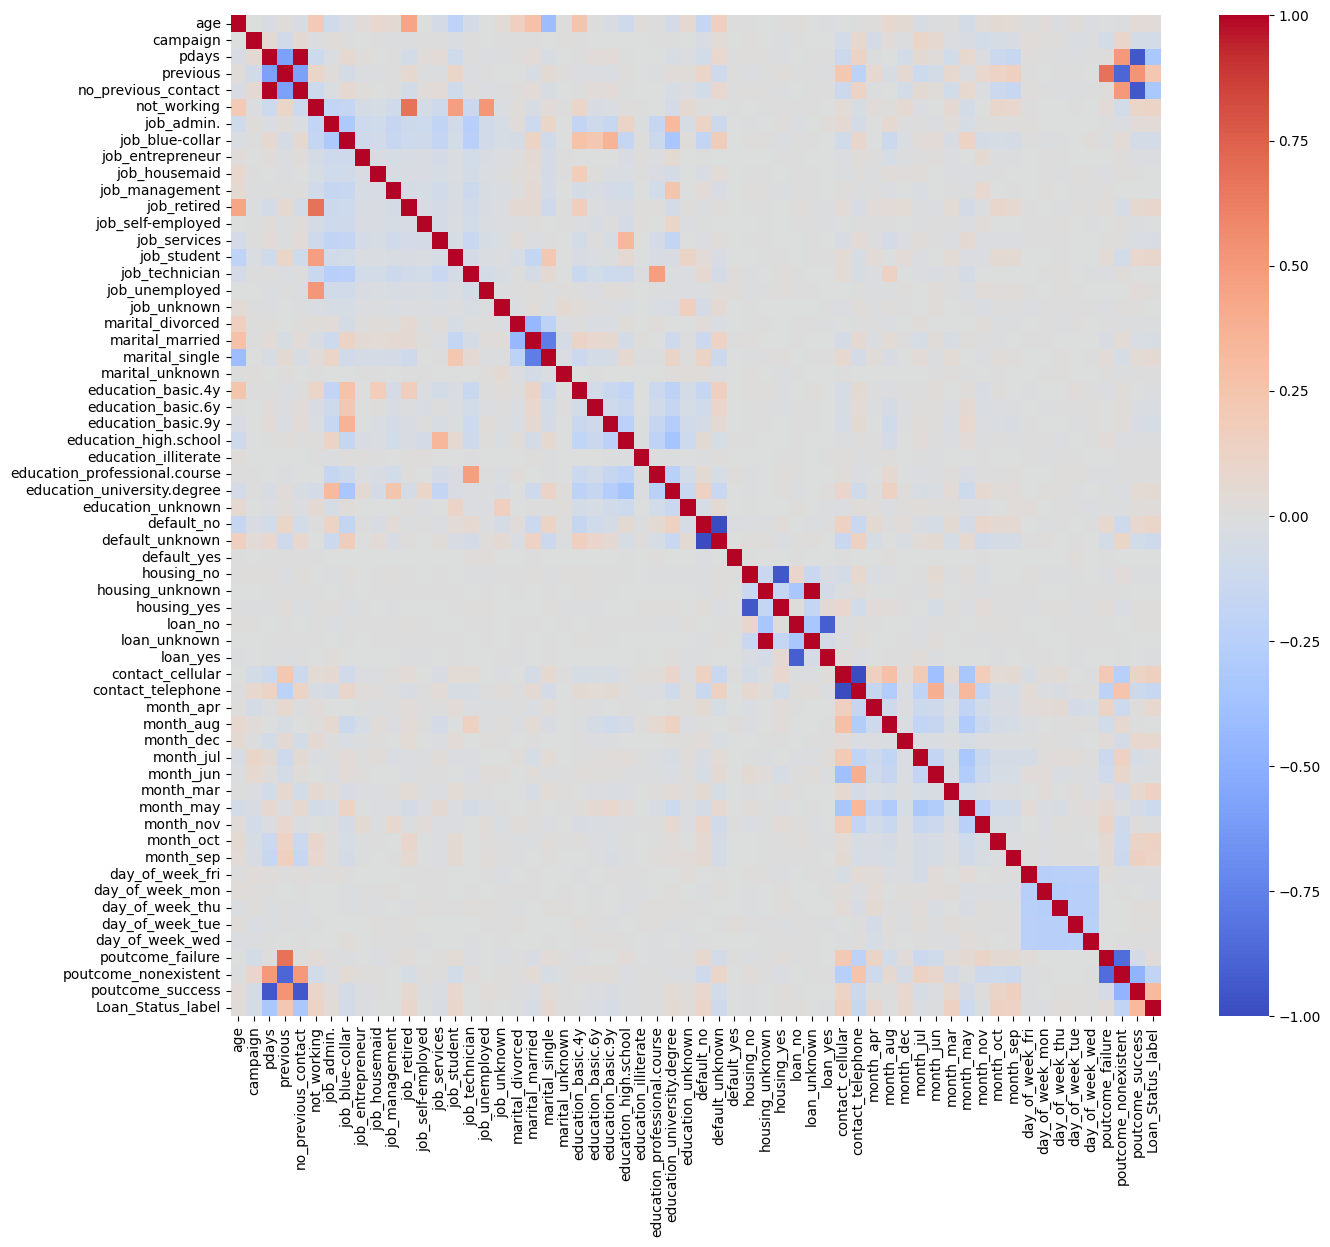

In [22]:
plt.figure(figsize=(15,13))
sns.heatmap(df.corr(),cmap='coolwarm')
plt.show()

Model Building

In [23]:
#Separating independent and dependent data

x=df.drop(columns=["Loan_Status_label"], axis=1)
y=df["Loan_Status_label"]

In [24]:
x

,age,campaign,pdays,previous,no_previous_contact,not_working,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,...,month_oct,month_sep,day_of_week_fri,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_failure,poutcome_nonexistent,poutcome_success
0,56,1,999,0,1,0,0,0,0,1,...,0,0,0,1,0,0,0,0,1,0
1,57,1,999,0,1,0,0,0,0,0,...,0,0,0,1,0,0,0,0,1,0
2,37,1,999,0,1,0,0,0,0,0,...,0,0,0,1,0,0,0,0,1,0
3,40,1,999,0,1,0,1,0,0,0,...,0,0,0,1,0,0,0,0,1,0
4,56,1,999,0,1,0,0,0,0,0,...,0,0,0,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,1,999,0,1,1,0,0,0,0,...,0,0,1,0,0,0,0,0,1,0
41184,46,1,999,0,1,0,0,1,0,0,...,0,0,1,0,0,0,0,0,1,0
41185,56,2,999,0,1,1,0,0,0,0,...,0,0,1,0,0,0,0,0,1,0
41186,44,1,999,0,1,0,0,0,0,0,...,0,0,1,0,0,0,0,0,1,0


In [25]:
y

0        0
1        0
2        0
3        0
4        0
        ..
41183    1
41184    0
41185    0
41186    1
41187    0
Name: Loan_Status_label, Length: 38771, dtype: int64

In [26]:
#Spliting data into train & test

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [27]:
X_train

,age,campaign,pdays,previous,no_previous_contact,not_working,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,...,month_oct,month_sep,day_of_week_fri,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_failure,poutcome_nonexistent,poutcome_success
34767,38,9,999,0,1,0,0,1,0,0,...,0,0,0,0,1,0,0,0,1,0
32132,36,1,999,1,1,0,0,0,0,0,...,0,0,1,0,0,0,0,1,0,0
9868,49,1,999,0,1,0,0,1,0,0,...,0,0,0,0,0,0,1,0,1,0
20192,36,9,999,0,1,0,0,0,0,1,...,0,0,0,1,0,0,0,0,1,0
28805,50,2,999,1,1,0,0,1,0,0,...,0,0,0,0,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6625,35,2,999,0,1,1,0,0,0,0,...,0,0,0,0,0,0,1,0,1,0
11843,31,3,999,0,1,0,1,0,0,0,...,0,0,1,0,0,0,0,0,1,0
40568,70,4,999,0,1,1,0,0,0,0,...,0,1,0,0,0,0,1,0,1,0
885,43,1,999,0,1,0,0,0,0,0,...,0,0,0,0,0,0,1,0,1,0


In [28]:
X_test

,age,campaign,pdays,previous,no_previous_contact,not_working,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,...,month_oct,month_sep,day_of_week_fri,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_failure,poutcome_nonexistent,poutcome_success
37815,57,1,999,1,1,1,0,0,0,0,...,0,0,0,0,0,0,1,1,0,0
5279,53,2,999,0,1,1,0,0,0,0,...,0,0,1,0,0,0,0,0,1,0
40810,30,1,999,3,1,0,0,0,0,0,...,0,1,0,0,1,0,0,1,0,0
3788,29,2,999,0,1,0,0,0,0,0,...,0,0,1,0,0,0,0,0,1,0
20910,30,1,999,0,1,0,0,0,0,0,...,0,0,0,0,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6833,35,2,999,0,1,0,0,1,0,0,...,0,0,0,0,0,0,1,0,1,0
18429,45,1,999,0,1,0,0,1,0,0,...,0,0,0,0,1,0,0,0,1,0
18590,28,2,999,0,1,0,0,0,0,0,...,0,0,0,0,1,0,0,0,1,0
4545,33,10,999,0,1,0,0,1,0,0,...,0,0,0,0,0,1,0,0,1,0


Feature Scaling

In [29]:
from sklearn.preprocessing import StandardScaler

In [30]:
sc = StandardScaler()
X_train_sc = sc.fit_transform(X_train)
X_test_sc = sc.transform(X_test)

In [31]:
X_train

,age,campaign,pdays,previous,no_previous_contact,not_working,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,...,month_oct,month_sep,day_of_week_fri,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_failure,poutcome_nonexistent,poutcome_success
34767,38,9,999,0,1,0,0,1,0,0,...,0,0,0,0,1,0,0,0,1,0
32132,36,1,999,1,1,0,0,0,0,0,...,0,0,1,0,0,0,0,1,0,0
9868,49,1,999,0,1,0,0,1,0,0,...,0,0,0,0,0,0,1,0,1,0
20192,36,9,999,0,1,0,0,0,0,1,...,0,0,0,1,0,0,0,0,1,0
28805,50,2,999,1,1,0,0,1,0,0,...,0,0,0,0,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6625,35,2,999,0,1,1,0,0,0,0,...,0,0,0,0,0,0,1,0,1,0
11843,31,3,999,0,1,0,1,0,0,0,...,0,0,1,0,0,0,0,0,1,0
40568,70,4,999,0,1,1,0,0,0,0,...,0,1,0,0,0,0,1,0,1,0
885,43,1,999,0,1,0,0,0,0,0,...,0,0,0,0,0,0,1,0,1,0


In [32]:
X_train_sc

array([[-0.21204265,  2.27564026,  0.20500869, ..., -0.34651856,
         0.40992066, -0.19507302],
       [-0.40249266, -0.58081638,  0.20500869, ...,  2.88584828,
        -2.43949646, -0.19507302],
       [ 0.8354324 , -0.58081638,  0.20500869, ..., -0.34651856,
         0.40992066, -0.19507302],
       ...,
       [ 2.83515749,  0.49035486,  0.20500869, ..., -0.34651856,
         0.40992066, -0.19507302],
       [ 0.26408237, -0.58081638,  0.20500869, ..., -0.34651856,
         0.40992066, -0.19507302],
       [ 0.26408237, -0.2237593 ,  0.20500869, ..., -0.34651856,
         0.40992066, -0.19507302]], shape=(31016, 59))

In [33]:
X_test_sc

array([[ 1.59723243, -0.58081638,  0.20500869, ...,  2.88584828,
        -2.43949646, -0.19507302],
       [ 1.21633241, -0.2237593 ,  0.20500869, ..., -0.34651856,
         0.40992066, -0.19507302],
       [-0.97384269, -0.58081638,  0.20500869, ...,  2.88584828,
        -2.43949646, -0.19507302],
       ...,
       [-1.1642927 , -0.2237593 ,  0.20500869, ..., -0.34651856,
         0.40992066, -0.19507302],
       [-0.68816768,  2.63269734,  0.20500869, ..., -0.34651856,
         0.40992066, -0.19507302],
       [-0.68816768,  0.13329778,  0.20500869, ..., -0.34651856,
         0.40992066, -0.19507302]], shape=(7755, 59))

Model Selection

In [39]:
#Logistic Regression

lg = LogisticRegression(max_iter=1000)
lg.fit(X_train_sc, y_train)
y_pred_log = lg.predict(X_test_sc)
print(f'Training Accuracy : {round(lg.score(X_train_sc,y_train),2)*100}%')
print(f'Test Accuracy : {round(lg.score(X_test_sc,y_test),2)*100}%')

Training Accuracy : 89.0%
Test Accuracy : 90.0%


In [44]:
#Decision Tree

dtree=DecisionTreeClassifier(max_depth=6)
dtree.fit(X_train_sc,y_train)
print(f'Training Accuracy : {round(dtree.score(X_train_sc,y_train),2)*100}%')
print(f'Test Accuracy : {round(dtree.score(X_test_sc,y_test),2)*100}%')

Training Accuracy : 89.0%
Test Accuracy : 90.0%


In [45]:
dtree=DecisionTreeClassifier(max_depth=5)
dtree.fit(X_train_sc,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


Model Prediction

In [50]:
y_pred_train = dtree.predict(X_train_sc)
y_pred_test = dtree.predict(X_test_sc)
X_train[:3]

,age,campaign,pdays,previous,no_previous_contact,not_working,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,...,month_oct,month_sep,day_of_week_fri,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_failure,poutcome_nonexistent,poutcome_success
34767,38,9,999,0,1,0,0,1,0,0,...,0,0,0,0,1,0,0,0,1,0
32132,36,1,999,1,1,0,0,0,0,0,...,0,0,1,0,0,0,0,1,0,0
9868,49,1,999,0,1,0,0,1,0,0,...,0,0,0,0,0,0,1,0,1,0


In [49]:
y_train[:3]

34767    0
32132    0
9868     0
Name: Loan_Status_label, dtype: int64

In [51]:
y_pred_train[:3]

array([0, 0, 0])

Model Evaluation

In [53]:
confusion_matrix(y_train,y_pred_train)

array([[26836,   449],
       [ 2859,   872]])

<Axes: >

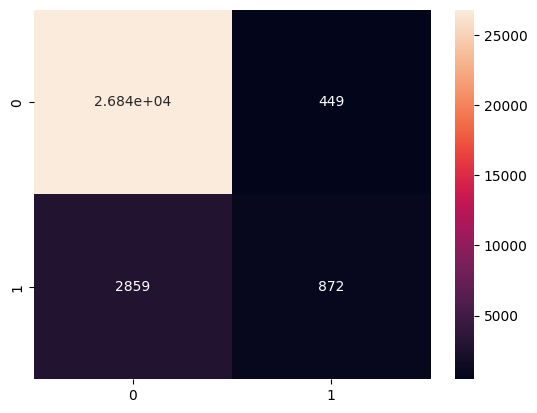

In [55]:
sns.heatmap(confusion_matrix(y_train,y_pred_train),annot=True,fmt='.4g')

In [57]:
accuracy_score(y_train,y_pred_train)

0.893345370131545

In [63]:
print(classification_report(y_train, y_pred_train))

              precision    recall  f1-score   support

           0       0.90      0.98      0.94     27285
           1       0.66      0.23      0.35      3731

    accuracy                           0.89     31016
   macro avg       0.78      0.61      0.64     31016
weighted avg       0.87      0.89      0.87     31016



SAMPLE TEST

In [64]:
x[:1]

,age,campaign,pdays,previous,no_previous_contact,not_working,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,...,month_oct,month_sep,day_of_week_fri,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_failure,poutcome_nonexistent,poutcome_success
0,56,1,999,0,1,0,0,0,0,1,...,0,0,0,1,0,0,0,0,1,0


In [65]:
y[:1]

0    0
Name: Loan_Status_label, dtype: int64

In [66]:
x.ndim

2

In [69]:
new_data = [[29,1,999,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0,0,0,1,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0]]
new_data

[[29,
  1,
  999,
  0,
  1,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  1,
  0,
  0,
  0,
  0,
  1,
  0,
  0,
  0,
  0,
  1,
  0,
  0,
  1,
  0,
  0,
  0,
  0,
  1,
  0,
  1,
  0,
  0,
  0,
  0,
  0,
  0,
  1,
  0,
  0,
  0,
  0,
  1,
  0,
  0,
  0,
  0,
  1,
  0,
  0]]

In [70]:
dtree.predict(new_data)

array([0])

In [72]:
new_data1 = [[29,1,999,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0,0,0,1,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,1]]
dtree.predict(new_data1)

array([0])

In [73]:
pip install -U notebook-as-pdf 

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for websockets: filename=websockets-10.4-cp313-cp313-win_amd64.whl size=95113 sha256=1e134ebbd67d10906bba99a7490b42e8b43bee8db571ab07ee5dd1fd5ee9e590
  Stored in directory: c:\users\pari\appdata\local\pip\cache\wheels\f5\dd\43\5b7132085406a982d2e0dd808f0ffed137865c8a8c5c7a5e4b
Successfully built websockets

   ---- ----------------------------------- 1/9 [zipp]
   -------- ------------------------------- 2/9 [websockets]
   -------- ------------------------------- 2/9 [websockets]
   -------- ------------------------------- 2/9 [websockets]
   -------- ------------------------------- 2/9 [websockets]
   -------- ------------------------------- 2/